# 01 Data Exploration



## Business Problem

A telecom provider wants to understand which customers are likely to cancel their contract. Losing an existing customer is usually more expensive than keeping one, so early churn signals can help the business decide where retention actions may be useful.

In this project, we use historical customer data to explore one central question:

> Can we predict whether a customer will churn based on demographic, contract, service, and billing information?

At this stage, we do not build a model yet. We first inspect the raw data and collect observations that will guide data cleaning, feature engineering, and baseline training.

## Dataset Story

The Telco Customer Churn dataset describes customers of a fictional telecom company. Each row represents one customer. The target column is `Churn`, which tells us whether the customer left the company.

The dataset combines several types of information:

- Customer attributes: `gender`, `SeniorCitizen`, `Partner`, `Dependents`
- Account information: `tenure`, `Contract`, `PaperlessBilling`, `PaymentMethod`
- Services used: `PhoneService`, `InternetService`, `OnlineSecurity`, `TechSupport`, streaming services, and related add-ons
- Billing information: `MonthlyCharges`, `TotalCharges`
- Target variable: `Churn`

From a machine learning perspective, this is a binary classification problem:

- `Churn = Yes`: customer churned
- `Churn = No`: customer stayed

The exploration should answer practical questions before modeling:

- How many customers and columns do we have?
- Is the target variable balanced?
- Which columns are numeric and which are categorical?
- Are there missing, blank, duplicated, or incorrectly typed values?
- Which customer groups show higher churn rates?

## Variable Definitions

These definitions describe the raw columns as we would receive them from a business or domain team before starting the technical analysis.

| Variable | Definition |
| --- | --- |
| `customerID` | Unique customer identifier. |
| `gender` | Customer gender. |
| `SeniorCitizen` | Whether the customer is a senior citizen (`1`) or not (`0`). |
| `Partner` | Whether the customer has a partner (`Yes`, `No`). |
| `Dependents` | Whether the customer has dependents, such as children or other family members (`Yes`, `No`). |
| `tenure` | Number of months the customer has stayed with the company. |
| `PhoneService` | Whether the customer has phone service (`Yes`, `No`). |
| `MultipleLines` | Whether the customer has multiple phone lines (`Yes`, `No`, `No phone service`). |
| `InternetService` | Customer's internet service type (`DSL`, `Fiber optic`, `No`). |
| `OnlineSecurity` | Whether the customer has online security (`Yes`, `No`, `No internet service`). |
| `OnlineBackup` | Whether the customer has online backup (`Yes`, `No`, `No internet service`). |
| `DeviceProtection` | Whether the customer has device protection (`Yes`, `No`, `No internet service`). |
| `TechSupport` | Whether the customer receives technical support (`Yes`, `No`, `No internet service`). |
| `StreamingTV` | Whether the customer uses streaming TV service (`Yes`, `No`, `No internet service`). |
| `StreamingMovies` | Whether the customer uses streaming movie service (`Yes`, `No`, `No internet service`). |
| `Contract` | Duration of the customer's contract (`Month-to-month`, `One year`, `Two year`). |
| `PaperlessBilling` | Whether the customer uses paperless billing (`Yes`, `No`). |
| `PaymentMethod` | Customer's payment method, such as electronic check, mailed check, bank transfer, or credit card. |
| `MonthlyCharges` | Amount charged to the customer per month. |
| `TotalCharges` | Total amount charged to the customer over the full customer relationship. |
| `Churn` | Target variable: whether the customer left the company (`Yes`) or stayed (`No`). |

The columns can also be grouped into broader business areas:

- Services: phone service, multiple lines, internet service, online security, online backup, device protection, technical support, streaming TV, and streaming movies.
- Account information: tenure, contract type, payment method, paperless billing, monthly charges, and total charges.
- Demographics: gender, senior citizen status, partner status, and dependents.
- Target: churn status.

## Notebook Scope

This notebook focuses only on exploration:

- Load the raw Telco Customer Churn dataset.
- Understand rows, columns, data types, and basic distributions.
- Inspect the target variable `Churn`.
- Identify data quality issues that should be handled during data cleaning.

This notebook does not train a model yet and does not modify the raw data.

## 1. Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

def find_project_root(start: Path) -> Path:
    for path in [start, *start.parents]:
        if (path / "data" / "raw" / "Telco-Customer-Churn.csv").exists():
            return path
    raise FileNotFoundError("Could not find project root with data/raw/Telco-Customer-Churn.csv")


PROJECT_ROOT = find_project_root(Path.cwd())
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "Telco-Customer-Churn.csv"

print(f"Project root: {PROJECT_ROOT}")
DATA_PATH

Project root: /home/patri/master/2026-06-ads-II-master


PosixPath('/home/patri/master/2026-06-ads-II-master/data/raw/Telco-Customer-Churn.csv')

## 2. Load Raw Data

In [2]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Raw data file not found: {DATA_PATH}\n"
        "Expected path: data/raw/Telco-Customer-Churn.csv"
    )

df = pd.read_csv(DATA_PATH)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

Rows: 7,043
Columns: 21


## 3. Column Overview

In [4]:
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Target Variable

In [7]:
target_counts = df["Churn"].value_counts()
target_share = df["Churn"].value_counts(normalize=True).mul(100).round(2)

pd.DataFrame({
    "count": target_counts,
    "share_percent": target_share,
})

,count,share_percent
Churn,,
No,5174,73.46
Yes,1869,26.54


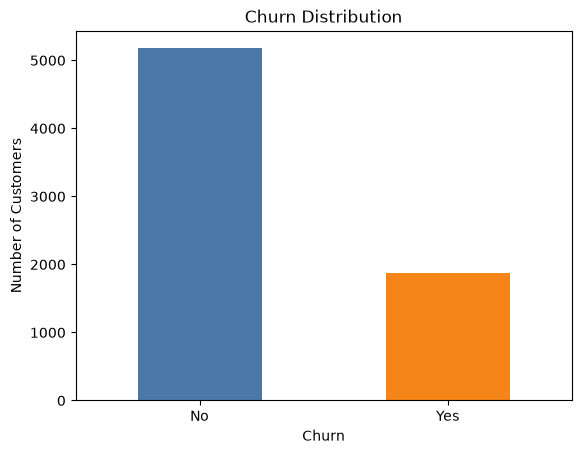

In [8]:
ax = target_counts.plot(kind="bar", color=["#4C78A8", "#F58518"])
ax.set_title("Churn Distribution")
ax.set_xlabel("Churn")
ax.set_ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

Initial observation:

The target variable is imbalanced. This is typical for churn prediction and is one reason why F1, precision, and recall are more useful than accuracy alone.

## 5. Missing Values and Duplicates

In [9]:
missing_summary = (
    df.isna()
    .sum()
    .rename("missing_count")
    .to_frame()
)
missing_summary["missing_share_percent"] = (
    missing_summary["missing_count"] / len(df) * 100
).round(2)
missing_summary.sort_values("missing_count", ascending=False)

,missing_count,missing_share_percent
customerID,0,0.0
gender,0,0.0
SeniorCitizen,0,0.0
Partner,0,0.0
Dependents,0,0.0
tenure,0,0.0
PhoneService,0,0.0
MultipleLines,0,0.0
InternetService,0,0.0
OnlineSecurity,0,0.0


In [10]:
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Duplicate customerID values: {df['customerID'].duplicated().sum()}")

Duplicate rows: 0
Duplicate customerID values: 0


## 6. Data Type Checks

In [11]:
dtype_summary = (
    df.dtypes
    .rename("dtype")
    .to_frame()
    .assign(unique_values=df.nunique())
)
dtype_summary

,dtype,unique_values
customerID,object,7043
gender,object,2
SeniorCitizen,int64,2
Partner,object,2
Dependents,object,2
tenure,int64,73
PhoneService,object,2
MultipleLines,object,3
InternetService,object,3
OnlineSecurity,object,3


`TotalCharges` is expected to be numeric, but in the original dataset it is often loaded as text because some values are blank. We inspect this before cleaning.

In [12]:
total_charges_numeric = pd.to_numeric(df["TotalCharges"], errors="coerce")

print(f"Original dtype: {df['TotalCharges'].dtype}")
print(f"Missing values after numeric conversion: {total_charges_numeric.isna().sum()}")

df.loc[total_charges_numeric.isna(), ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]].head(20)

Original dtype: object
Missing values after numeric conversion: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


## 7. Numerical Features

Numerical features are variables where distances and magnitudes are meaningful. In this dataset, `tenure`, `MonthlyCharges`, and the cleaned version of `TotalCharges` are the main numerical variables.

`SeniorCitizen` is stored as `0` and `1`, but it is not a metric variable. It is a binary customer attribute and is easier to interpret together with categorical or binary features.


In [13]:
numeric_columns = ["tenure", "MonthlyCharges"]

numeric_summary = df[numeric_columns].describe().T
numeric_summary


,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


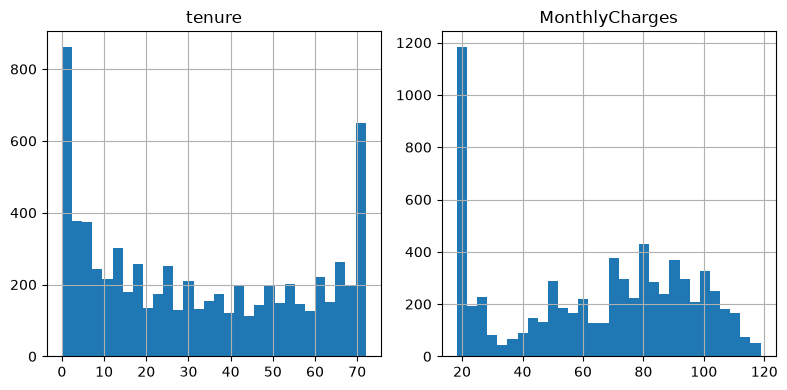

In [14]:
df[numeric_columns].hist(figsize=(8, 4), bins=30)
plt.tight_layout()
plt.show()


## 8. Binary and Categorical Feature Note

`SeniorCitizen` is a useful example of a common data science distinction: storage type and semantic type are not always the same.

- Storage type: integer (`0` or `1`)
- Semantic type: binary categorical feature

For exploration, we therefore inspect it like a group attribute and compare churn rates for senior and non-senior customers.


In [15]:
senior_churn = (
    df.groupby("SeniorCitizen")["Churn"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("share_percent")
    .reset_index()
    .pivot(index="SeniorCitizen", columns="Churn", values="share_percent")
    .round(2)
)

senior_churn


Churn,No,Yes
SeniorCitizen,,
0,76.39,23.61
1,58.32,41.68


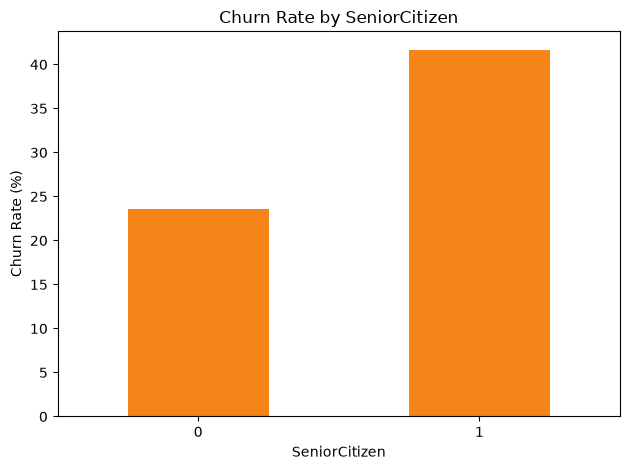

In [16]:
senior_churn["Yes"].plot(kind="bar", color="#F58518")
plt.title("Churn Rate by SeniorCitizen")
plt.ylabel("Churn Rate (%)")
plt.xlabel("SeniorCitizen")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 9. Categorical Features


In [17]:
categorical_columns = df.select_dtypes(include="object").columns.tolist()

# SeniorCitizen is stored as an integer, but semantically it is binary categorical.
categorical_columns = categorical_columns + ["SeniorCitizen"]
categorical_columns


['customerID',
 'gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'TotalCharges',
 'Churn',
 'SeniorCitizen']

In [18]:
for column in categorical_columns:
    print(f"\n{column}")
    print(df[column].value_counts(dropna=False).head(20))


customerID
customerID
7590-VHVEG    1
5575-GNVDE    1
3668-QPYBK    1
7795-CFOCW    1
9237-HQITU    1
9305-CDSKC    1
1452-KIOVK    1
6713-OKOMC    1
7892-POOKP    1
6388-TABGU    1
9763-GRSKD    1
7469-LKBCI    1
8091-TTVAX    1
0280-XJGEX    1
5129-JLPIS    1
3655-SNQYZ    1
8191-XWSZG    1
9959-WOFKT    1
4190-MFLUW    1
4183-MYFRB    1
Name: count, dtype: int64

gender
gender
Male      3555
Female    3488
Name: count, dtype: int64

Partner
Partner
No     3641
Yes    3402
Name: count, dtype: int64

Dependents
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

PhoneService
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

MultipleLines
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

InternetService
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

OnlineSecurity
OnlineSecurity
No                     3498
Yes                    2019
No inte

## 10. Churn by Selected Features

In [19]:
def churn_rate_by(column: str) -> pd.DataFrame:
    return (
        df.groupby(column)["Churn"]
        .value_counts(normalize=True)
        .mul(100)
        .rename("share_percent")
        .reset_index()
        .pivot(index=column, columns="Churn", values="share_percent")
        .round(2)
        .sort_values("Yes", ascending=False)
    )


churn_rate_by("Contract")

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


In [20]:
churn_rate_by("InternetService")

Churn,No,Yes
InternetService,,
Fiber optic,58.11,41.89
DSL,81.04,18.96
No,92.60,7.40


In [21]:
churn_rate_by("PaymentMethod")

Churn,No,Yes
PaymentMethod,,
Electronic check,54.71,45.29
Mailed check,80.89,19.11
Bank transfer (automatic),83.29,16.71
Credit card (automatic),84.76,15.24


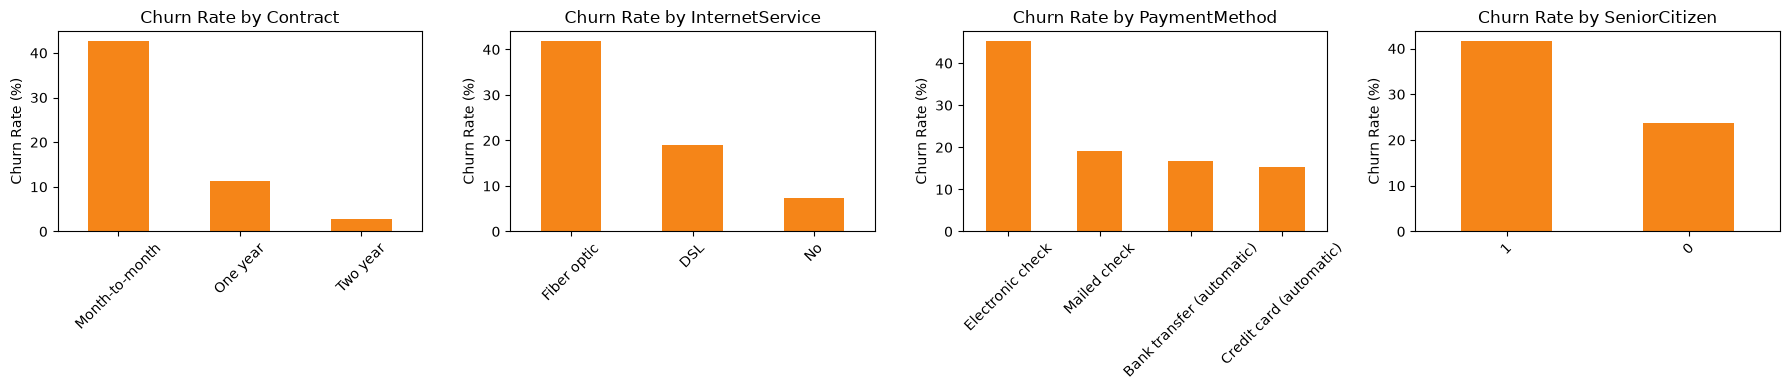

In [22]:
selected_columns = ["Contract", "InternetService", "PaymentMethod", "SeniorCitizen"]

fig, axes = plt.subplots(1, len(selected_columns), figsize=(18, 4))

for ax, column in zip(axes, selected_columns):
    rates = churn_rate_by(column)["Yes"].sort_values(ascending=False)
    rates.plot(kind="bar", ax=ax, color="#F58518")
    ax.set_title(f"Churn Rate by {column}")
    ax.set_ylabel("Churn Rate (%)")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


## 11. Exploration Summary

Key findings for the next step:

- `customerID` is an identifier and should not be used as a model feature.
- `Churn` is the target variable and must be encoded as `Yes -> 1`, `No -> 0`.
- `TotalCharges` needs cleaning because it is loaded as text and contains blank values.
- Most columns are categorical and will need encoding before modeling.
- `SeniorCitizen` is stored as `0`/`1`, but semantically it is a binary categorical customer attribute.
- Numerical columns such as `tenure`, `MonthlyCharges`, and `TotalCharges` should be handled consistently.
- The target distribution is imbalanced, so evaluation should not rely on accuracy alone.

Next notebook step: data cleaning.
